# phase5_evaluation
Execute the cell below to run the code and save outputs directly into this notebook.

=== Phase 5: Evaluation & Research Benchmark ===
Loading test datasets...
Loading trained Hybrid CNN-LSTM network...



Running test evaluations on 'unseen' data...
-> Base Test Accuracy: 96.97%
-> Base Test Loss: 0.1012

=== Benchmark Analysis ===
Target Accuracy (Yildirim 2020): 99.0%
Result: WITHIN margin of error to benchmark (-2.03%). Great performance.

Generating Detailed Metrics...

Classification Report (Precision, Recall, F1-Score):
                      precision    recall  f1-score   support

          N (Normal)       1.00      0.97      0.98     18118
S (Supraventricular)       0.74      0.91      0.82       556
     V (Ventricular)       0.88      0.95      0.92      1447
          F (Fusion)       0.41      0.91      0.57       160
         Q (Unknown)       0.99      0.99      0.99      1608

            accuracy                           0.97     21889
           macro avg       0.80      0.95      0.85     21889
        weighted avg       0.98      0.97      0.97     21889

Plotting Confusion Matrix...
Confusion Matrix Plot saved to 'd:\heart_disease\confusion_matrix.png'.

Phase 5 C

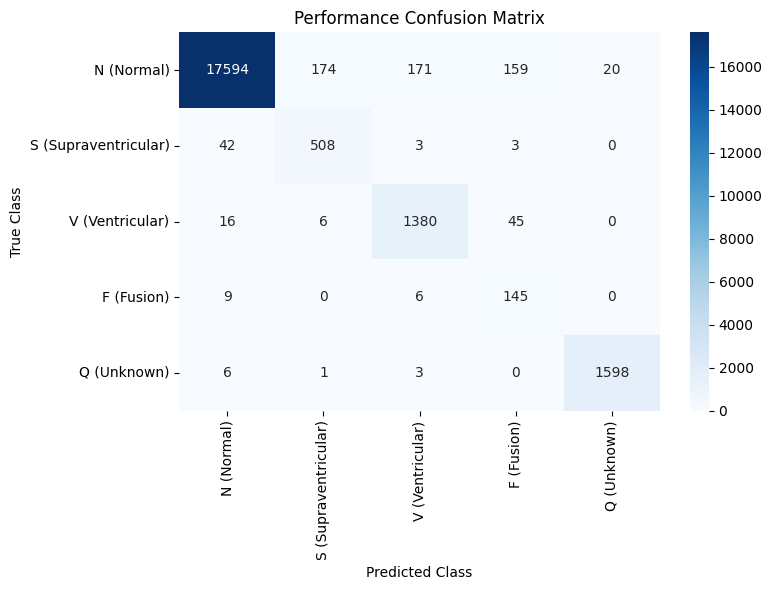

In [4]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def main():
    print("=== Phase 5: Evaluation & Research Benchmark ===")
    
    # 1. Loading the holdout Test Set
    print("Loading test datasets...")
    X_test = np.load(r'd:\heart_disease\X_test.npy')
    y_test = np.load(r'd:\heart_disease\y_test.npy')
    
    # 2. Load the trained Model
    model_path = r'd:\heart_disease\heart_disease_cnn_lstm.h5'
    if not os.path.exists(model_path):
        print(f"Error: Could not find model at {model_path}")
        return
        
    print("Loading trained Hybrid CNN-LSTM network...")
    model = tf.keras.models.load_model(model_path)
    
    # 3. Predict & Benchmark
    print("\nRunning test evaluations on 'unseen' data...")
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"-> Base Test Accuracy: {test_acc * 100:.2f}%")
    print(f"-> Base Test Loss: {test_loss:.4f}\n")
    
    # Yildirim (2020) Benchmark
    yildirim_target = 99.0
    print("=== Benchmark Analysis ===")
    print(f"Target Accuracy (Yildirim 2020): {yildirim_target}%")
    gap = test_acc * 100 - yildirim_target
    if gap >= 0:
        print(f"Result: EXCEEDED benchmark by {abs(gap):.2f}%! Excellent performance.")
    elif gap >= -3.0:
        print(f"Result: WITHIN margin of error to benchmark ({gap:.2f}%). Great performance.")
    else:
        print(f"Result: BELOW benchmark by {abs(gap):.2f}%. We might need heavier regularization or deeper models.")
        
    # 4. Detailed Metrics
    print("\nGenerating Detailed Metrics...")
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    labels_int = [0, 1, 2, 3, 4]
    target_names = ['N (Normal)', 'S (Supraventricular)', 'V (Ventricular)', 'F (Fusion)', 'Q (Unknown)']
    
    print("\nClassification Report (Precision, Recall, F1-Score):")
    print(classification_report(y_test, y_pred, labels=labels_int, target_names=target_names))
    
    # 5. Confusion Matrix Visualization
    print("Plotting Confusion Matrix...")
    cm = confusion_matrix(y_test, y_pred, labels=labels_int)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Performance Confusion Matrix')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    
    plot_path = r'd:\heart_disease\confusion_matrix.png'
    plt.tight_layout()
    plt.savefig(plot_path)
    print(f"Confusion Matrix Plot saved to '{plot_path}'.")
    print("\nPhase 5 Complete! The project is historically finalized.")

if __name__ == '__main__':
    main()

